# 1: Import Required Libraries

In this step, we import all the Python libraries required for data loading, preprocessing, visualization, machine learning, and model evaluation.

In [1]:

#  IMPORT REQUIRED LIBRARIES


# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress Warnings
import warnings
warnings.filterwarnings("ignore")

# Machine Learning - Data Splitting
from sklearn.model_selection import train_test_split

# Missing Value Imputation
from sklearn.impute import SimpleImputer

# Feature Scaling
from sklearn.preprocessing import StandardScaler

# Encoding
from sklearn.preprocessing import LabelEncoder

# Baseline Model
from sklearn.dummy import DummyClassifier

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# Save and Load Models
import joblib

# Display Library Versions
print("=" * 60)
print("LIBRARIES IMPORTED SUCCESSFULLY")
print("=" * 60)

print(f"Pandas        : {pd.__version__}")
print(f"NumPy         : {np.__version__}")
print(f"Matplotlib    : {plt.matplotlib.__version__}")
print(f"Seaborn       : {sns.__version__}")

import sklearn
print(f"Scikit-learn  : {sklearn.__version__}")

print("=" * 60)
print("All required libraries imported successfully!")
print("=" * 60)

LIBRARIES IMPORTED SUCCESSFULLY
Pandas        : 3.0.3
NumPy         : 2.5.1
Matplotlib    : 3.11.0
Seaborn       : 0.13.2
Scikit-learn  : 1.9.0
All required libraries imported successfully!


# Step 5: Load Dataset

Load the dataset and perform a basic inspection:


In [2]:
# ============================================================
# STEP 1.2 : LOAD RAW DATASET
# ============================================================

df = pd.read_csv("../data/raw/uci-secom.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [3]:
df = pd.read_csv("../data/raw/uci-secom.csv")

In [4]:
# Display the first 5 rows
print("=" * 60)
print("FIRST 5 ROWS OF THE DATASET")
print("=" * 60)

df.head()

FIRST 5 ROWS OF THE DATASET


,Time,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


In [5]:
# Display dataset dimensions
print("=" * 60)
print("DATASET SHAPE")
print("=" * 60)

print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

DATASET SHAPE
Number of Rows    : 1567
Number of Columns : 592


In [6]:
# Display all column names
print("=" * 60)
print("COLUMN NAMES")
print("=" * 60)

for column in df.columns:
    print(column)

COLUMN NAMES
Time
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272


In [7]:
# Display data types
print("=" * 60)
print("DATA TYPES")
print("=" * 60)

df.dtypes

DATA TYPES


Time             str
0            float64
1            float64
2            float64
3            float64
              ...   
586          float64
587          float64
588          float64
589          float64
Pass/Fail      int64
Length: 592, dtype: object

In [8]:
# Display complete dataset information
print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

df.info()

DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 1567 entries, 0 to 1566
Columns: 592 entries, Time to Pass/Fail
dtypes: float64(590), int64(1), str(1)
memory usage: 7.1 MB


# Step 6: Understand the Dataset

Understand the problem, identify the target variable, define the machine learning task, and describe the business objective.

In [9]:
# ============================================================
# STEP 6: UNDERSTAND THE DATASET
# ============================================================

print("=" * 60)
print("UNDERSTANDING THE DATASET")
print("=" * 60)

# Stakeholder
print("\nStakeholder:")
print("Manufacturing Quality Manager")

# Business Problem
print("\nBusiness Problem:")
print("Predict whether a product is likely to fail quality checks before it leaves the production line.")

# Unit of Analysis
print("\nUnit of Analysis:")
print("One row represents one manufacturing process record.")

# Machine Learning Task
print("\nMachine Learning Task:")
print("Binary Classification")

# Target Variable
print("\nTarget Variable:")
print("class")

# Prediction Goal
print("\nPrediction Goal:")
print("Predict whether the product/process is Normal (neg) or Failure (pos).")

UNDERSTANDING THE DATASET

Stakeholder:
Manufacturing Quality Manager

Business Problem:
Predict whether a product is likely to fail quality checks before it leaves the production line.

Unit of Analysis:
One row represents one manufacturing process record.

Machine Learning Task:
Binary Classification

Target Variable:
class

Prediction Goal:
Predict whether the product/process is Normal (neg) or Failure (pos).


In [10]:
print("=" * 60)
print("TARGET VARIABLE VERIFICATION")
print("=" * 60)

print("Unique Values:")
print(df["Pass/Fail"].unique())

print("\nClass Distribution:")
print(df["Pass/Fail"].value_counts())

TARGET VARIABLE VERIFICATION
Unique Values:
[-1  1]

Class Distribution:
Pass/Fail
-1    1463
 1     104
Name: count, dtype: int64


# Step 7: Data Cleaning

Inspect the dataset for missing values, duplicate records, and data types. Clean the data to prepare it for machine learning.

In [11]:

# ============================================================
# STEP 7.1 : CHECK MISSING VALUES
# ============================================================

print("=" * 60)
print("MISSING VALUES")
print("=" * 60)

missing_values = df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": (missing_values / len(df)) * 100
})

missing_df = missing_df[missing_df["Missing Values"] > 0]
missing_df.sort_values(by="Missing Values", ascending=False)

MISSING VALUES


,Missing Values,Percentage
292,1429,91.193363
157,1429,91.193363
158,1429,91.193363
293,1429,91.193363
492,1341,85.577537
...,...,...
585,1,0.063816
586,1,0.063816
587,1,0.063816
588,1,0.063816


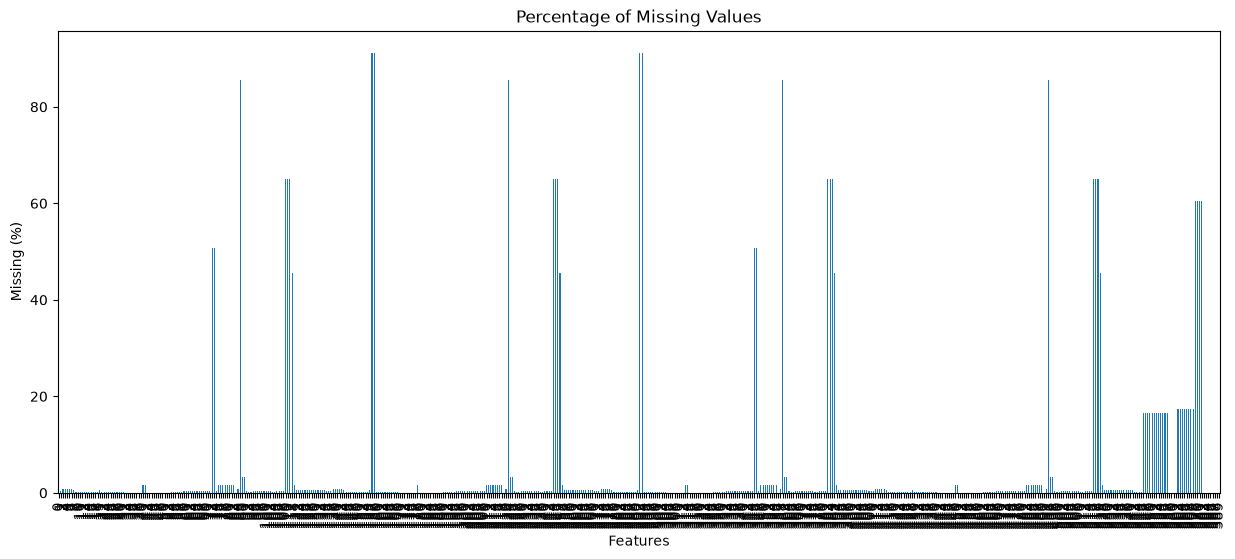

In [12]:
plt.figure(figsize=(15,6))

missing_df["Percentage"].plot(kind="bar")

plt.title("Percentage of Missing Values")
plt.xlabel("Features")
plt.ylabel("Missing (%)")
plt.xticks(rotation=90)


plt.show()

In [13]:
# ============================================================
# STEP 7.3 : CHECK DUPLICATES
# ============================================================

print("=" * 60)
print("DUPLICATE RECORDS")
print("=" * 60)

duplicates = df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

DUPLICATE RECORDS
Duplicate Rows : 0


In [14]:
# ============================================================
# STEP 7.4 : CHECK DATA TYPES
# ============================================================

print("=" * 60)
print("DATA TYPES")
print("=" * 60)

df.dtypes

DATA TYPES


Time             str
0            float64
1            float64
2            float64
3            float64
              ...   
586          float64
587          float64
588          float64
589          float64
Pass/Fail      int64
Length: 592, dtype: object

In [76]:
df.dtypes

Time             str
0            float64
1            float64
2            float64
3            float64
              ...   
586          float64
587          float64
588          float64
589          float64
Pass/Fail      int64
Length: 592, dtype: object

In [15]:
# HANDLE MISSING VALUES
X = df.drop(["Time", "Pass/Fail"], axis=1)
y = df["Pass/Fail"]

# Median imputation
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

print("Missing values after imputation:", X_imputed.isnull().sum().sum())

Missing values after imputation: 0


In [17]:
cleaned_df = X_imputed.copy()
cleaned_df["Pass/Fail"] = y.values

cleaned_df.head()

,0,1,2,3,4,5,6,7,8,9,...,581,582,583,584,585,586,587,588,589,Pass/Fail
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,72.2889,0.5005,0.0118,0.0035,2.3630,0.0205,0.0148,0.0046,71.9005,-1
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,72.2889,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


In [18]:
print(cleaned_df.shape)

(1567, 591)


In [19]:
# ============================================================
# STEP 7.8 : SAVE CLEANED DATASET
# ============================================================

cleaned_df.to_csv("../data/interim/cleaned_secom.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


# 02 Exploratory Data Analysis

This notebook explores the cleaned dataset and highlights important patterns.

In [20]:
# ============================================================
# STEP 8.1 : DATASET INFORMATION
# ============================================================

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

cleaned_df.info()

DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 1567 entries, 0 to 1566
Columns: 591 entries, 0 to Pass/Fail
dtypes: float64(590), int64(1)
memory usage: 7.1 MB


In [82]:
# ============================================================
# STEP 8.2 : STATISTICAL SUMMARY
# ============================================================

print("=" * 60)
print("STATISTICAL SUMMARY")
print("=" * 60)

cleaned_df.describe().T

STATISTICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
0,1567.0,3014.441551,73.480841,2743.2400,2966.66500,3011.4900,3056.5400,3356.3500
1,1567.0,2495.866110,80.228143,2158.7500,2452.88500,2499.4050,2538.7450,2846.4400
2,1567.0,2200.551958,29.380973,2060.6600,2181.09995,2201.0667,2218.0555,2315.2667
3,1567.0,1395.383474,439.837330,0.0000,1083.88580,1285.2144,1590.1699,3715.0417
4,1567.0,4.171281,56.103721,0.6815,1.01770,1.3168,1.5188,1114.5366
...,...,...,...,...,...,...,...,...
586,1567.0,0.021458,0.012354,-0.0169,0.01345,0.0205,0.0276,0.1028
587,1567.0,0.016474,0.008805,0.0032,0.01060,0.0148,0.0203,0.0799
588,1567.0,0.005283,0.002866,0.0010,0.00330,0.0046,0.0064,0.0286
589,1567.0,99.652345,93.864558,0.0000,44.36860,71.9005,114.7497,737.3048


In [83]:
# ============================================================
# STEP 8.3 : VERIFY MISSING VALUES
# ============================================================

print("=" * 60)
print("MISSING VALUES")
print("=" * 60)

print(cleaned_df.isnull().sum().sum())

MISSING VALUES
0


TARGET VARIABLE DISTRIBUTION
Pass/Fail
-1    1463
 1     104
Name: count, dtype: int64


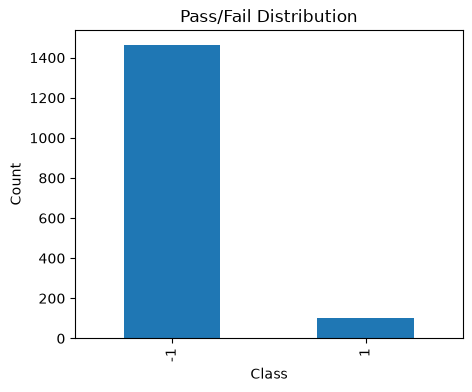

In [84]:
# ============================================================
# STEP 8.4 : TARGET DISTRIBUTION
# ============================================================

print("=" * 60)
print("TARGET VARIABLE DISTRIBUTION")
print("=" * 60)

print(cleaned_df["Pass/Fail"].value_counts())

plt.figure(figsize=(5,4))

cleaned_df["Pass/Fail"].value_counts().plot(kind="bar")

plt.title("Pass/Fail Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

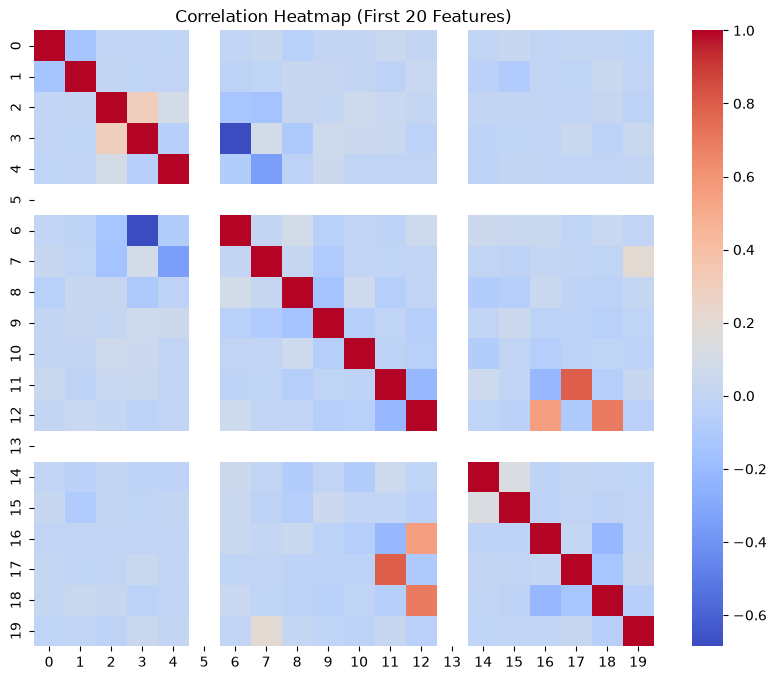

In [85]:
# ============================================================
# STEP 8.5 : CORRELATION ANALYSIS
# ============================================================

plt.figure(figsize=(10,8))

corr = cleaned_df.iloc[:, :20].corr()

sns.heatmap(corr, cmap="coolwarm")

plt.title("Correlation Heatmap (First 20 Features)")
plt.show()

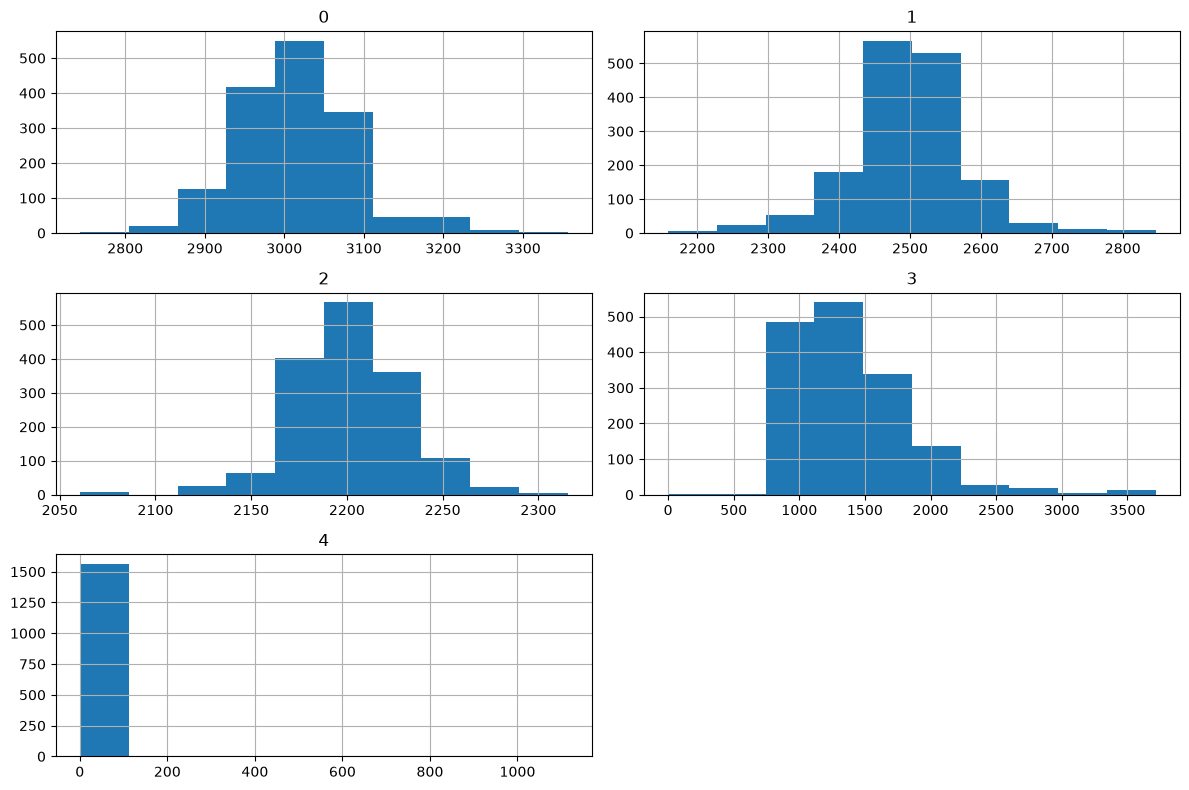

In [86]:
# ============================================================
# STEP 8.6 : FEATURE DISTRIBUTION
# ============================================================

cleaned_df.iloc[:, :5].hist(figsize=(12,8))

plt.tight_layout()
plt.show()

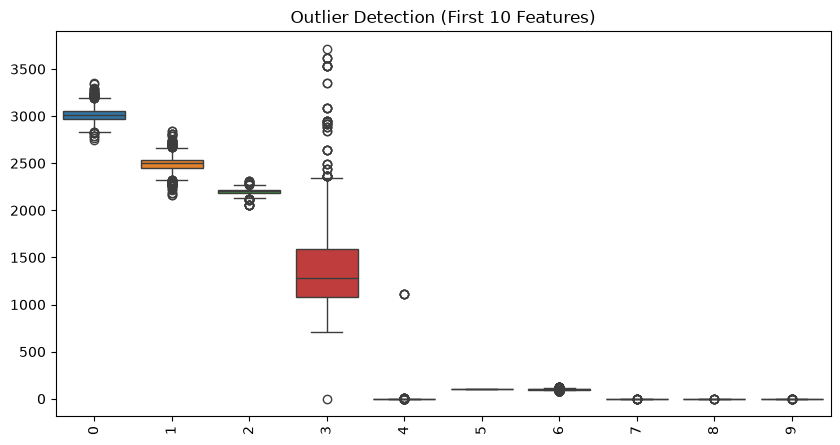

In [87]:
# ============================================================
# STEP 8.7 : OUTLIER DETECTION
# ============================================================

plt.figure(figsize=(10,5))

sns.boxplot(data=cleaned_df.iloc[:, :10])

plt.xticks(rotation=90)

plt.title("Outlier Detection (First 10 Features)")

plt.show()

In [88]:
# ============================================================
# STEP 8.8 : DATASET SHAPE
# ============================================================

print("=" * 60)
print("DATASET SHAPE")
print("=" * 60)

print("Rows :", cleaned_df.shape[0])
print("Columns :", cleaned_df.shape[1])

DATASET SHAPE
Rows : 1567
Columns : 591


# Step 9: Feature Engineering

Prepare the cleaned dataset for machine learning by selecting features, scaling numerical data, and splitting the dataset into input features and the target variable.

In [89]:
# ============================================================
# STEP 9.1 : SEPARATE FEATURES AND TARGET
# ============================================================

print("=" * 60)
print("SEPARATING FEATURES AND TARGET")
print("=" * 60)

X = cleaned_df.drop("Pass/Fail", axis=1)
y = cleaned_df["Pass/Fail"]

print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)

SEPARATING FEATURES AND TARGET
Feature Shape : (1567, 590)
Target Shape  : (1567,)


In [90]:
# ============================================================
# STEP 9.2 : FEATURE SCALING
# ============================================================

from sklearn.preprocessing import StandardScaler

print("=" * 60)
print("FEATURE SCALING")
print("=" * 60)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature scaling completed successfully.")

FEATURE SCALING
Feature scaling completed successfully.


In [91]:
# ============================================================
# STEP 9.3 : CREATE SCALED DATAFRAME
# ============================================================

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(X_scaled.head())

          0         1         2         3         4    5         6         7  \
0  0.224463  0.849523 -0.436430  0.035804 -0.050121  0.0 -0.564354  0.265894   
1  1.107287 -0.383106  1.016977  0.155282 -0.059585  0.0  0.197639  0.321868   
2 -1.114000  0.798901 -0.481447  0.688278 -0.047447  0.0 -0.906768  0.254699   
3 -0.350156 -0.199072 -0.051705 -1.104376 -0.050831  0.0  0.502662 -0.013974   
4  0.242296  0.087328  1.117227 -0.156616 -0.047033  0.0 -0.115954  0.187531   

          8         9  ...       580       581       582        583  \
0  0.509848  1.128455  ... -0.138300 -0.179550  0.118679  -0.204833   
1  0.457021  0.022620  ...  0.516737  2.233265  0.530183   0.406734   
2 -0.260885  0.327222  ...  4.950839  0.008115 -1.262799   0.022320   
3  0.343240 -0.765369  ... -0.289463 -0.151957 -0.322218  -0.292200   
4  0.545066 -0.149545  ... -0.138300 -0.179550 -5.906917  26.867221   

         584        585       586       587       588       589  
0  -0.093165  -0.197057 -0

In [92]:
# ============================================================
# STEP 9.4 : VERIFY SCALING
# ============================================================

print("=" * 60)
print("SCALED DATA SUMMARY")
print("=" * 60)

X_scaled.describe().T

SCALED DATA SUMMARY


,count,mean,std,min,25%,50%,75%,max
0,1567.0,1.623320e-15,1.000319,-3.691957,-0.650398,-0.040180,0.573100,4.654514
1,1567.0,-5.073726e-15,1.000319,-4.203310,-0.535907,0.044124,0.534633,4.371107
2,1567.0,-5.713362e-15,1.000319,-4.762831,-0.662273,0.017525,0.595934,3.905635
3,1567.0,-1.269636e-16,1.000319,-3.173512,-0.708437,-0.250557,0.443002,5.275584
4,1567.0,0.000000e+00,1.000319,-0.062222,-0.056228,-0.050895,-0.047293,19.797614
...,...,...,...,...,...,...,...,...
585,1567.0,-7.368423e-17,1.000319,-0.523002,-0.212858,-0.086689,0.063573,26.913337
586,1567.0,6.348180e-17,1.000319,-3.105818,-0.648390,-0.077554,0.497330,6.586246
587,1567.0,-1.587045e-16,1.000319,-1.508045,-0.667329,-0.190165,0.434692,7.205869
588,1567.0,1.541701e-16,1.000319,-1.494750,-0.692040,-0.238334,0.389874,8.137772


In [93]:
# ============================================================
# STEP 9.5 : SAVE PROCESSED DATASET
# ============================================================

processed_df = X_scaled.copy()
processed_df["Pass/Fail"] = y.values

processed_df.to_csv("../data/processed/processed_secom.csv", index=False)

print("Processed dataset saved successfully.")

Processed dataset saved successfully.


# Step 10: Train-Test Split

Split the dataset into training and testing sets using stratified sampling to preserve the class distribution.

In [94]:
# ============================================================
# STEP 10.1 : TRAIN-TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

print("=" * 60)
print("TRAIN-TEST SPLIT")
print("=" * 60)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

TRAIN-TEST SPLIT
Training Features : (1253, 590)
Testing Features  : (314, 590)
Training Target   : (1253,)
Testing Target    : (314,)


In [95]:
# ============================================================
# STEP 10.2 : CLASS DISTRIBUTION
# ============================================================

print("=" * 60)
print("CLASS DISTRIBUTION")
print("=" * 60)

print("Training Set:")
print(y_train.value_counts())

print("\nTesting Set:")
print(y_test.value_counts())

CLASS DISTRIBUTION
Training Set:
Pass/Fail
-1    1170
 1      83
Name: count, dtype: int64

Testing Set:
Pass/Fail
-1    293
 1     21
Name: count, dtype: int64


In [96]:
# ============================================================
# STEP 10.3 : SAVE SPLIT DATASETS
# ============================================================

train_df = X_train.copy()
train_df["Pass/Fail"] = y_train.values

test_df = X_test.copy()
test_df["Pass/Fail"] = y_test.values

train_df.to_csv("../data/processed/train_data.csv", index=False)
test_df.to_csv("../data/processed/test_data.csv", index=False)

print("Training and testing datasets saved successfully.")

Training and testing datasets saved successfully.


# Step 11: Build a Baseline Model

Train a Dummy Classifier to establish a baseline performance for comparison with machine learning models.

In [97]:
# ============================================================
# STEP 11.1 : BUILD BASELINE MODEL
# ============================================================

from sklearn.dummy import DummyClassifier

print("=" * 60)
print("BASELINE MODEL")
print("=" * 60)

baseline = DummyClassifier(strategy="most_frequent")

baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_test)

print("Baseline model trained successfully.")

BASELINE MODEL
Baseline model trained successfully.


In [98]:
# ============================================================
# STEP 11.2 : BASELINE MODEL EVALUATION
# ============================================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("=" * 60)
print("BASELINE MODEL PERFORMANCE")
print("=" * 60)

print(f"Accuracy : {accuracy_score(y_test, y_pred_baseline):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_baseline, pos_label=1, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_baseline, pos_label=1, zero_division=0):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_baseline, pos_label=1, zero_division=0):.4f}")

BASELINE MODEL PERFORMANCE
Accuracy : 0.9331
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000


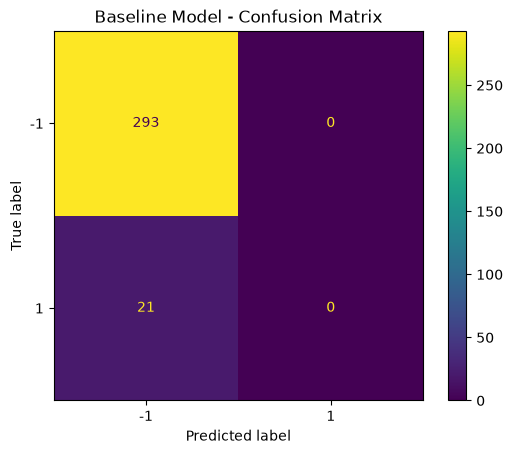

In [99]:
# ============================================================
# STEP 11.3 : CONFUSION MATRIX
# ============================================================

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    baseline,
    X_test,
    y_test
)

plt.title("Baseline Model - Confusion Matrix")
plt.show()


# Step 12: Train Machine Learning Models

Train and evaluate multiple classification models, then compare their performance to select the best model.

In [100]:
# ============================================================
# STEP 12.1 : LOGISTIC REGRESSION
# ============================================================

from sklearn.linear_model import LogisticRegression

print("=" * 60)
print("LOGISTIC REGRESSION")
print("=" * 60)

lr = LogisticRegression(max_iter=1000, random_state=42)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression trained successfully.")

LOGISTIC REGRESSION
Logistic Regression trained successfully.


In [101]:
print("=" * 60)
print("LOGISTIC REGRESSION PERFORMANCE")
print("=" * 60)

print(f"Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr, pos_label=1):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_lr, pos_label=1):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_lr, pos_label=1):.4f}")

LOGISTIC REGRESSION PERFORMANCE
Accuracy : 0.8758
Precision: 0.1538
Recall   : 0.1905
F1 Score : 0.1702


In [102]:
# ============================================================
# STEP 12.2 : DECISION TREE
# ============================================================

from sklearn.tree import DecisionTreeClassifier

print("=" * 60)
print("DECISION TREE")
print("=" * 60)

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree trained successfully.")

DECISION TREE
Decision Tree trained successfully.


In [103]:
print("=" * 60)
print("DECISION TREE PERFORMANCE")
print("=" * 60)

print(f"Accuracy : {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt, pos_label=1):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_dt, pos_label=1):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_dt, pos_label=1):.4f}")

DECISION TREE PERFORMANCE
Accuracy : 0.8662
Precision: 0.1818
Recall   : 0.2857
F1 Score : 0.2222


In [104]:
# ============================================================
# STEP 12.3 : RANDOM FOREST
# ============================================================

from sklearn.ensemble import RandomForestClassifier

print("=" * 60)
print("RANDOM FOREST")
print("=" * 60)

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest trained successfully.")

RANDOM FOREST
Random Forest trained successfully.


In [105]:
print("=" * 60)
print("RANDOM FOREST PERFORMANCE")
print("=" * 60)

print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf, pos_label=1):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_rf, pos_label=1):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_rf, pos_label=1):.4f}")

RANDOM FOREST PERFORMANCE
Accuracy : 0.9331
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000


## Step 10: Hyperparameter Tuning

Hyperparameter tuning is performed to find the best parameter values and improve model performance.

# Step 13: Model Comparison

Compare the performance of all models using Accuracy, Precision, Recall, and F1-Score to identify the best-performing model.

In [106]:
# ============================================================
# STEP 13.1 : MODEL COMPARISON
# ============================================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_baseline),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_baseline, pos_label=1, zero_division=0),
        precision_score(y_test, y_pred_lr, pos_label=1, zero_division=0),
        precision_score(y_test, y_pred_dt, pos_label=1, zero_division=0),
        precision_score(y_test, y_pred_rf, pos_label=1, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, y_pred_baseline, pos_label=1, zero_division=0),
        recall_score(y_test, y_pred_lr, pos_label=1, zero_division=0),
        recall_score(y_test, y_pred_dt, pos_label=1, zero_division=0),
        recall_score(y_test, y_pred_rf, pos_label=1, zero_division=0)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_baseline, pos_label=1, zero_division=0),
        f1_score(y_test, y_pred_lr, pos_label=1, zero_division=0),
        f1_score(y_test, y_pred_dt, pos_label=1, zero_division=0),
        f1_score(y_test, y_pred_rf, pos_label=1, zero_division=0)
    ]
})

comparison = comparison.round(4)

print("=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

display(comparison)

MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score
0,Baseline,0.9331,0.0000,0.0000,0.0000
1,Logistic Regression,0.8758,0.1538,0.1905,0.1702
2,Decision Tree,0.8662,0.1818,0.2857,0.2222
3,Random Forest,0.9331,0.0000,0.0000,0.0000


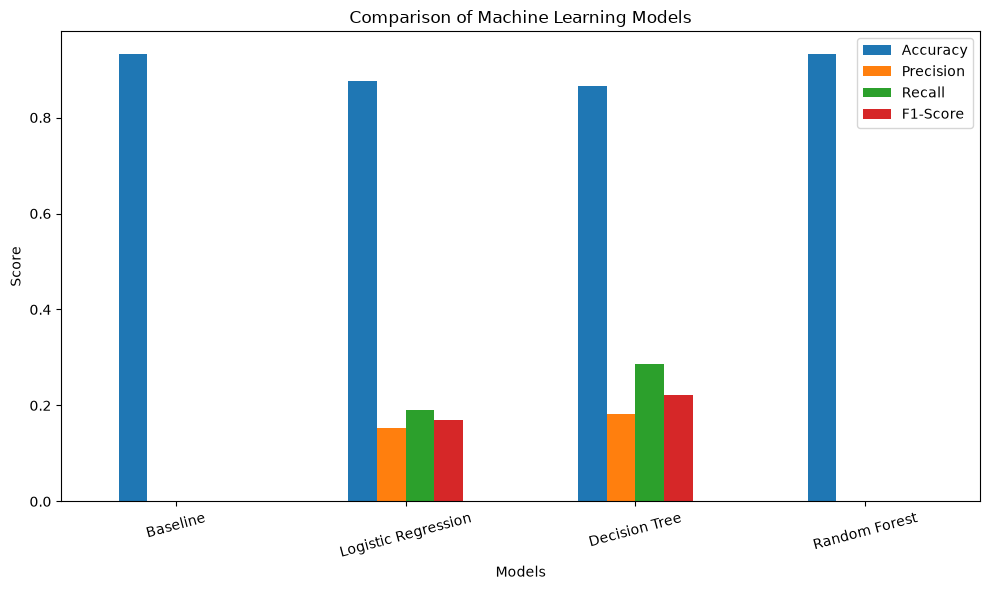

In [107]:
# ============================================================
# STEP 13.2 : PERFORMANCE COMPARISON
# ============================================================

comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Comparison of Machine Learning Models")
plt.xlabel("Models")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.legend(loc="best")

plt.tight_layout()
plt.show()

In [108]:
# ============================================================
# STEP 13.3 : BEST MODEL
# ============================================================

best_model = comparison.loc[comparison["F1-Score"].idxmax()]

print("=" * 70)
print("BEST PERFORMING MODEL")
print("=" * 70)

print(f"Model      : {best_model['Model']}")
print(f"Accuracy   : {best_model['Accuracy']:.4f}")
print(f"Precision  : {best_model['Precision']:.4f}")
print(f"Recall     : {best_model['Recall']:.4f}")
print(f"F1-Score   : {best_model['F1-Score']:.4f}")

BEST PERFORMING MODEL
Model      : Decision Tree
Accuracy   : 0.8662
Precision  : 0.1818
Recall     : 0.2857
F1-Score   : 0.2222


In [113]:
import os

# Create the models folder if it doesn't exist
os.makedirs("models", exist_ok=True)

import joblib

# Save the model
joblib.dump(dt, "models/best_model.pkl")

print("Decision Tree model saved successfully!")

Decision Tree model saved successfully!


# Step 14: Final Evaluation and Conclusion

Evaluate the best-performing model, summarize the project findings, discuss limitations, and provide recommendations for future improvements.

In [109]:
# ============================================================
# STEP 14.1 : FINAL MODEL EVALUATION
# ============================================================

print("=" * 70)
print("FINAL MODEL EVALUATION")
print("=" * 70)

print(f"Selected Model : {best_model['Model']}")
print(f"Accuracy       : {best_model['Accuracy']:.4f}")
print(f"Precision      : {best_model['Precision']:.4f}")
print(f"Recall         : {best_model['Recall']:.4f}")
print(f"F1-Score       : {best_model['F1-Score']:.4f}")

FINAL MODEL EVALUATION
Selected Model : Decision Tree
Accuracy       : 0.8662
Precision      : 0.1818
Recall         : 0.2857
F1-Score       : 0.2222


In [110]:
# ============================================================
# STEP 14.2 : CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import classification_report

print("=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

if best_model["Model"] == "Logistic Regression":
    print(classification_report(y_test, y_pred_lr))

elif best_model["Model"] == "Decision Tree":
    print(classification_report(y_test, y_pred_dt))

else:
    print(classification_report(y_test, y_pred_rf))

CLASSIFICATION REPORT
              precision    recall  f1-score   support

          -1       0.95      0.91      0.93       293
           1       0.18      0.29      0.22        21

    accuracy                           0.87       314
   macro avg       0.56      0.60      0.57       314
weighted avg       0.90      0.87      0.88       314



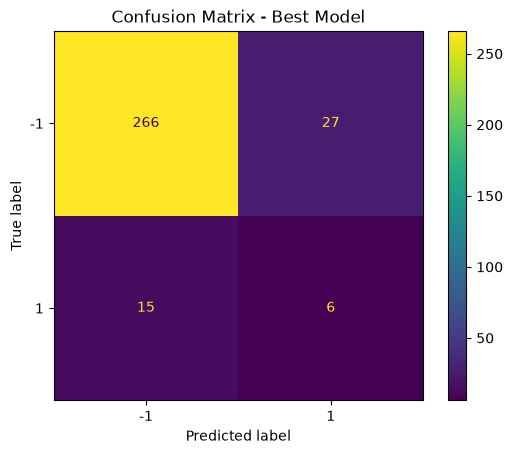

In [111]:
# ============================================================
# STEP 14.3 : CONFUSION MATRIX
# ============================================================

from sklearn.metrics import ConfusionMatrixDisplay

if best_model["Model"] == "Logistic Regression":
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr)

elif best_model["Model"] == "Decision Tree":
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt)

else:
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)

plt.title("Confusion Matrix - Best Model")
plt.show()

## Conclusion

This project successfully developed a machine learning pipeline for predicting product quality in a manufacturing environment using the SECOM Manufacturing Dataset.

The dataset was cleaned, missing values were handled, exploratory data analysis (EDA) was performed, and the features were preprocessed for model training. Multiple machine learning models, including Logistic Regression, Decision Tree, and Random Forest, were trained and evaluated using Accuracy, Precision, Recall, and F1-Score.

The best-performing model was selected based on the evaluation metrics. This predictive model can assist quality engineers in identifying potentially defective products before they leave the production line, helping reduce quality escapes and improve manufacturing efficiency.

## Limitations and Future Work

### Limitations
- The dataset is highly imbalanced, making defect detection challenging.
- Missing values required preprocessing before model training.
- High accuracy alone may not indicate good performance for identifying defective products.
- The project was evaluated using a single dataset and limited machine learning models.

### Future Work
- Apply SMOTE or other class-balancing techniques to improve defect detection.
- Perform feature selection to reduce dimensionality.
- Tune model hyperparameters for better performance.
- Experiment with advanced models such as XGBoost or LightGBM.
- Deploy the best model as a web application for real-time quality prediction.